Transition from yield to weekly predicted progress of corn based on weather and soil condition. Why did we shift to predicting Planting Progress based on weekly weather?

Farmers are practical experts: Historically, farmers plant their corn when the weekly weather and soil conditions are absolutely perfect (not too muddy, not too cold).
Decoding the "Ideal" Week: By training a model to predict the Planting Progress percentage based solely on weather, we are essentially training it to recognize what the perfect planting conditions look like.
The Yield Connection: If we feed a future weather forecast into this new model and it predicts a massive spike in planting progress (e.g., 97% in Week 22), it's telling us: "These are the optimal conditions to get your seeds in the ground."
Because planting during the optimal window is one of the strongest predictors of a high yield, this weekly progress model acts as an early-warning scheduling tool. It tells the farmer exactly which week to plant to set the crop up for maximum yield success months later

Another way of thinking is that the model is saying that these weather conditions (the ones provided) are historically perfect; this is the optimal week to get your seeds in the ground."

**Model Overview:**
We utilized an **XGBoost Regressor** (Extreme Gradient Boosting) to predict the weekly planting progress (`PCT PLANTED`) for corn in Texas. XGBoost is a powerful, tree-based ensemble machine learning algorithm that is highly effective at capturing non-linear relationships in data.

**Features (Inputs):**
The model makes its decisions based on the time of year (`Week_Number`) and high-resolution weekly weather data from NASA: Average Temperature (`T2M`), Maximum Temperature (`T2M_MAX`), Minimum Temperature (`T2M_MIN`), Precipitation (`PRECTOTCORR`), and Relative Humidity (`RH2M`).

**Performance Metrics:**
*   **R-Squared ($R^2$): 0.904** - This is an excellent score. It means that the model can explain approximately 90.4% of the variance in how quickly corn is planted. The time of year combined with weather conditions strongly dictates planting behavior.
*   **RMSE (Root Mean Squared Error): 7.79%** - This means that, on average, the model's prediction for how much of the crop is planted in a given week is off by only about 7.79 percentage points.

**Testing Methodology:**
Our dataset contains historical data from 2005 to 2024. During the training phase, we randomly withheld 20% of this historical data. The model was evaluated by predicting the planting progress for these withheld "past weeks" and comparing its predictions against the actual historical records.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# Load the dataset and convert dates
df_weekly = pd.read_csv('MASTER_WEEKLY_2005_2024.csv')
df_weekly['Week_Ending'] = pd.to_datetime(df_weekly['Week_Ending'])

# Display basic information and summary statistics
print(df_weekly.info())
print("\nSummary Statistics:")
display(df_weekly.describe())

# Check for missing values
print("\nMissing Values per Column:")
display(df_weekly.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Week_Ending  1699 non-null   datetime64[ns]
 1   T2M          1699 non-null   float64       
 2   T2M_MAX      1699 non-null   float64       
 3   T2M_MIN      1699 non-null   float64       
 4   PRECTOTCORR  1699 non-null   float64       
 5   RH2M         1699 non-null   float64       
 6   Year         1699 non-null   int64         
 7   state_alpha  1699 non-null   object        
 8   unit_desc    1699 non-null   object        
 9   Value        1699 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(2), object(2)
memory usage: 132.9+ KB
None

Summary Statistics:


,Week_Ending,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,Year,Value
count,1699,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,2016-06-19 23:49:49.758681600,22.757401,30.295708,15.749189,1.759504,49.942199,2015.910536,70.419070
min,2005-04-17 00:00:00,-2.184286,3.531429,-6.507143,0.000000,16.318571,2005.000000,0.000000
25%,2012-05-20 00:00:00,18.745714,26.572143,11.704286,0.122857,41.634286,2012.000000,56.000000
50%,2016-11-06 00:00:00,24.295714,31.067143,17.664286,0.902857,49.060000,2016.000000,74.000000
75%,2021-04-18 00:00:00,27.454286,34.717143,20.574286,2.454286,58.345714,2021.000000,93.000000
max,2024-11-10 00:00:00,32.635714,40.867143,24.775714,16.058571,86.348571,2024.000000,100.000000
std,NaN,6.061106,5.877360,6.190504,2.376720,12.240525,5.525740,25.285783



Missing Values per Column:


,0
Week_Ending,0
T2M,0
T2M_MAX,0
T2M_MIN,0
PRECTOTCORR,0
RH2M,0
Year,0
state_alpha,0
unit_desc,0
Value,0


In [48]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [49]:
print("TRAINING WEEKLY PLANTING MODEL")

# Filter dataset for planting progress only
df_planting = df_weekly[df_weekly['unit_desc'] == 'PCT PLANTED'].copy()

# Extract Week Number as a feature to capture seasonality
df_planting['Week_Number'] = df_planting['Week_Ending'].dt.isocalendar().week

# Define Features (X) and Target (y)
# We use the weather metrics and the week number to predict the planting percentage
features = ['Week_Number', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
X_weekly = df_planting[features]
y_weekly = df_planting['Value']

# Train/Test Split (80% training, 20% testing)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weekly, y_weekly, test_size=0.2, random_state=42)

# Initialize and Train XGBoost
xgb_weekly = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_weekly.fit(X_train_w, y_train_w)

# Predict and Evaluate
y_pred_w = xgb_weekly.predict(X_test_w)
r2_w = r2_score(y_test_w, y_pred_w)
rmse_w = np.sqrt(mean_squared_error(y_test_w, y_pred_w))

print(f"\nWEEKLY XGBOOST RESULTS:")
print(f"Data points available for PCT PLANTED: {len(df_planting)}")
print(f"R-Squared: {r2_w:.3f}")
print(f"RMSE: {rmse_w:.2f} %")

# Show Feature Importances
importances_w = xgb_weekly.feature_importances_
feat_df_w = pd.DataFrame({'Feature': features, 'Importance': importances_w}).sort_values(by='Importance', ascending=False)
display(feat_df_w)

TRAINING WEEKLY PLANTING MODEL

WEEKLY XGBOOST RESULTS:
Data points available for PCT PLANTED: 253
R-Squared: 0.904
RMSE: 7.79 %


,Feature,Importance
0,Week_Number,0.943735
3,T2M_MIN,0.018085
2,T2M_MAX,0.009832
5,RH2M,0.009829
4,PRECTOTCORR,0.009737
1,T2M,0.008782


### Simulating Example of how to use Model below.

In [50]:
print("SIMULATING OPTIMAL PLANTING WEEK")

# Define the typical spring planting window (Weeks 10 to 22)
spring_weeks = list(range(10, 23))

# Calculate average historical weather conditions for these weeks to use as our simulation baseline
avg_weather = df_planting[df_planting['Week_Number'].isin(spring_weeks)].groupby('Week_Number')[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']].mean().reset_index()

print("Simulating planting progress for typical Spring weeks (10-22) using historical averages...")

# Predict planting progress for these simulated weeks
# Ensure the columns match the exact order used during training
simulated_features = avg_weather[['Week_Number', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']]
avg_weather['Predicted_PCT_PLANTED'] = xgb_weekly.predict(simulated_features)

# Identify the optimal week (the one with the highest predicted planting percentage)
optimal_week = avg_weather.loc[avg_weather['Predicted_PCT_PLANTED'].idxmax()]

print(f"\n OPTIMAL PLANTING WEEK: Week {int(optimal_week['Week_Number'])}")
print(f"Predicted Progress: {optimal_week['Predicted_PCT_PLANTED']:.2f}%")
print(f"Average Temp (T2M): {optimal_week['T2M']:.2f}°C")

print("\nTop 5 Recommended Weeks:")
display(avg_weather[['Week_Number', 'Predicted_PCT_PLANTED']].sort_values(by='Predicted_PCT_PLANTED', ascending=False).head(5))


SIMULATING OPTIMAL PLANTING WEEK
Simulating planting progress for typical Spring weeks (10-22) using historical averages...

 OPTIMAL PLANTING WEEK: Week 22
Predicted Progress: 97.56%
Average Temp (T2M): 23.42°C

Top 5 Recommended Weeks:


,Week_Number,Predicted_PCT_PLANTED
12,22,97.557686
11,21,93.088608
10,20,92.945404
9,19,80.660507
8,18,73.407326


VISUALIZING ACTUAL VS PREDICTED PLANTING PROGRESS


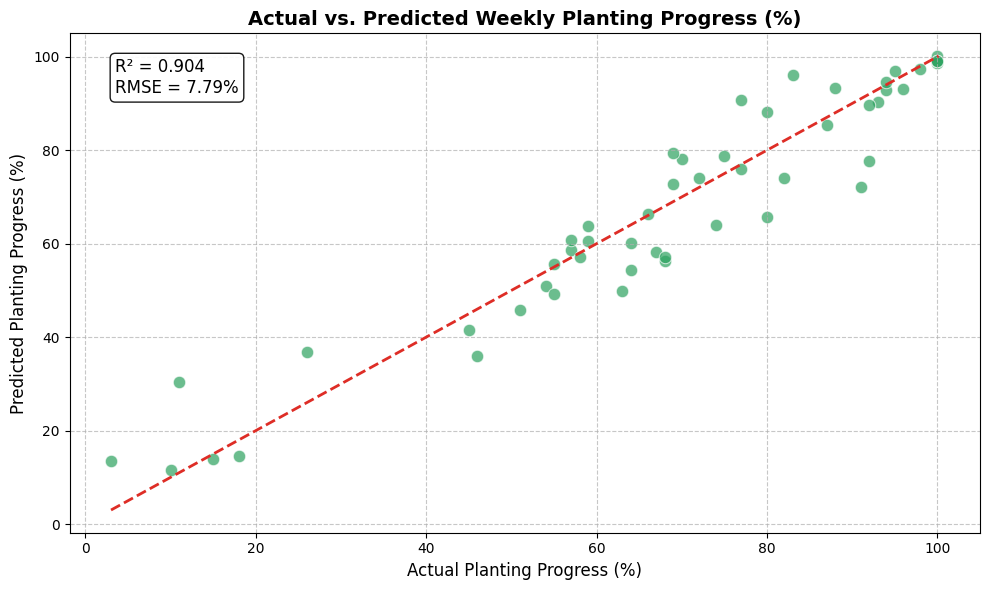

In [51]:
print("VISUALIZING ACTUAL VS PREDICTED PLANTING PROGRESS")

# Create a figure
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs predicted values using the test set
sns.scatterplot(x=y_test_w, y=y_pred_w, alpha=0.7, color='#2ca25f', edgecolor='w', s=80)

# Draw the perfect prediction line (y=x)
min_val = min(y_test_w.min(), y_pred_w.min())
max_val = max(y_test_w.max(), y_pred_w.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', lw=2, color='#de2d26')

plt.title('Actual vs. Predicted Weekly Planting Progress (%)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Planting Progress (%)', fontsize=12)
plt.ylabel('Predicted Planting Progress (%)', fontsize=12)

# Add a text box displaying our metrics
plt.text(0.05, 0.95, f'R² = {r2_w:.3f}\nRMSE = {rmse_w:.2f}%',
         transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [52]:
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV

In [53]:
print("CROSS-VALIDATION OF WEEKLY PLANTING MODEL")

# Initialize a 5-Fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculate R-squared scores across the 5 folds
cv_r2_scores = cross_val_score(xgb_weekly, X_weekly, y_weekly, cv=kf, scoring='r2', n_jobs=-1)

# Calculate RMSE scores (cross_val_score returns negative MSE/RMSE by default, so we negate it)
cv_rmse_scores = -cross_val_score(xgb_weekly, X_weekly, y_weekly, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)

print(f"5-Fold Cross Validation Results:")
print(f"R-Squared Scores (each fold): {np.round(cv_r2_scores, 3)}")
print(f"Mean CV R-Squared: {np.mean(cv_r2_scores):.3f} (Std Dev: ±{np.std(cv_r2_scores):.3f})")
print(f"\nRMSE Scores (each fold): {np.round(cv_rmse_scores, 2)}%")
print(f"Mean CV RMSE: {np.mean(cv_rmse_scores):.2f}% (Std Dev: ±{np.std(cv_rmse_scores):.2f}%)")

CROSS-VALIDATION OF WEEKLY PLANTING MODEL
5-Fold Cross Validation Results:
R-Squared Scores (each fold): [0.904 0.928 0.917 0.923 0.916]
Mean CV R-Squared: 0.918 (Std Dev: ±0.008)

RMSE Scores (each fold): [7.79 6.75 7.21 7.65 8.68]%
Mean CV RMSE: 7.62% (Std Dev: ±0.65%)


In [54]:
print("XGBOOST HYPERPARAMETER OPTIMIZATION")

# Define the grid of hyperparameters to search
param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Initialize a base XGBoost model
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# Set up the RandomizedSearchCV
# Which will randomly sample 20 combinations from the param_grid and use 3-Fold CV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,         # Number of parameter settings that are sampled
    scoring='r2',      # Optimize for R-Squared
    cv=3,              # 3-Fold Cross-Validation
    verbose=1,         # Print progress
    random_state=42,
    n_jobs=-1          # Use all available CPU cores
)

# Run the search on our weekly training data
print("Running randomized search... (this might take a minute)")
random_search.fit(X_train_w, y_train_w)

# Extract the best parameters and the optimized model
best_params = random_search.best_params_
best_xgb_model = random_search.best_estimator_

print("\nOptimization Complete!")
print(f"Best Hyperparameters Found:\n{best_params}")

# 6. Evaluate the optimized model on the test set
y_pred_opt = best_xgb_model.predict(X_test_w)
r2_opt = r2_score(y_test_w, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test_w, y_pred_opt))

print(f"\nOPTIMIZED MODEL RESULTS:")
print(f"R-Squared: {r2_opt:.3f} (Before Optimization: {r2_w:.3f})")
print(f"RMSE: {rmse_opt:.2f}% (Before Optimization: {rmse_w:.2f}%)")

XGBOOST HYPERPARAMETER OPTIMIZATION
Running randomized search... (this might take a minute)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Optimization Complete!
Best Hyperparameters Found:
{'subsample': 0.8, 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}

OPTIMIZED MODEL RESULTS:
R-Squared: 0.911 (Before Optimization: 0.904)
RMSE: 7.52% (Before Optimization: 7.79%)


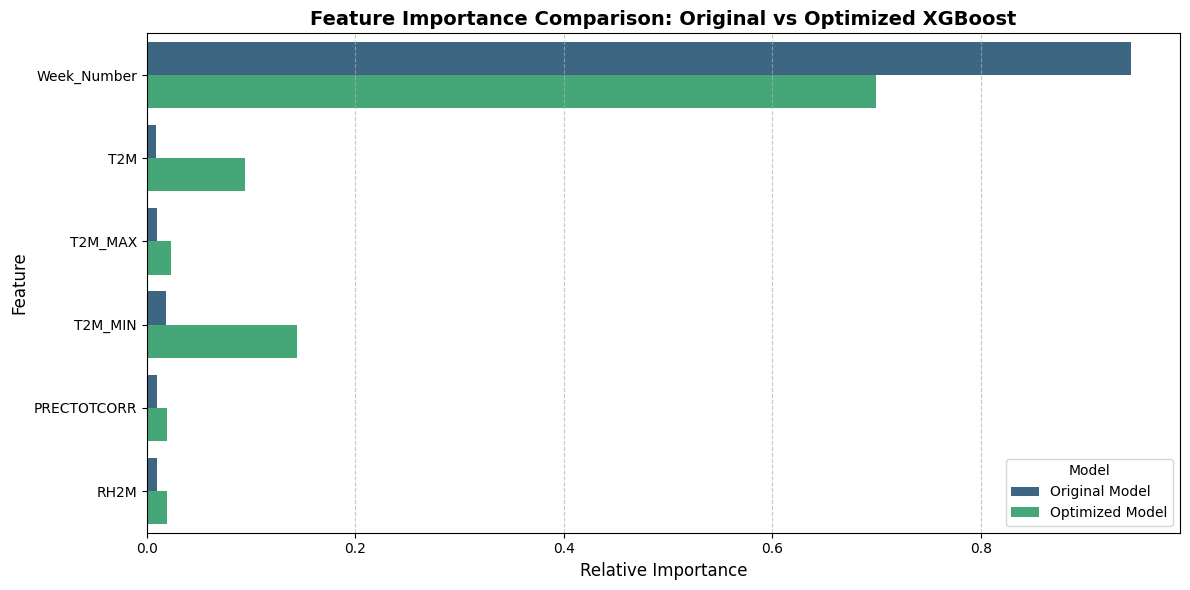

,Feature,Original Model,Optimized Model
0,Week_Number,0.943735,0.699569
3,T2M_MIN,0.018085,0.144157
1,T2M,0.008782,0.094420
2,T2M_MAX,0.009832,0.023047
4,PRECTOTCORR,0.009737,0.019832
5,RH2M,0.009829,0.018975


In [55]:
# Get feature importances from both models
importances_orig = xgb_weekly.feature_importances_
importances_opt = best_xgb_model.feature_importances_

# Create a DataFrame for comparison
feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Original Model': importances_orig,
    'Optimized Model': importances_opt
})

# Melt the DataFrame for easier plotting with seaborn
feat_imp_melted = feat_imp_df.melt(id_vars='Feature', var_name='Model', value_name='Importance')

# Plot the comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', hue='Model', data=feat_imp_melted, palette='viridis')
plt.title('Feature Importance Comparison: Original vs Optimized XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the raw values
display(feat_imp_df.sort_values(by='Optimized Model', ascending=False))

In [56]:
# Save the optimized XGBoost model

# model_filename_opt = 'xgb_weekly_planting_model_optimized.json'
# best_xgb_model.save_model(model_filename_opt)
# print(f"\n✅ Optimized model successfully saved to {model_filename_opt}")

### Another Example of how a farmer would use our model.

A high percentage like 90% means that they should plant if they are wanting to start planting.

A lower percentage would mean that the crop (corn) would have bad progress leading to a lower yield.

In [57]:
print("PREDICTING ON NEW WEATHER FORECAST")

# Create a hypothetical new weather forecast for Week 15 (Mid-April)
new_weather_data = pd.DataFrame({
    'Week_Number': [15],
    'T2M': [18.5],         # Average Temp (C)
    'T2M_MAX': [26.0],     # Max Temp (C)
    'T2M_MIN': [10.0],     # Min Temp (C)
    'PRECTOTCORR': [1.2],  # Precipitation (mm)
    'RH2M': [55.0]         # Relative Humidity (%)
})

print("New Weather Forecast:")
display(new_weather_data)

# Ensure the columns match the exact order expected by the model
features = ['Week_Number', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']
new_weather_features = new_weather_data[features]

# Predict using the optimized model
# (We can use best_xgb_model directly since it's still in memory,
# or you could load it from 'xgb_weekly_planting_model_optimized.json' as shown in Step 19)
predicted_progress_opt = best_xgb_model.predict(new_weather_features)

print(f"\nPredicted Planting Progress for Week {new_weather_data['Week_Number'][0]}: {predicted_progress_opt[0]:.2f}%")

PREDICTING ON NEW WEATHER FORECAST
New Weather Forecast:


,Week_Number,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M
0,15,18.5,26.0,10.0,1.2,55.0



Predicted Planting Progress for Week 15: 52.57%
